<a href="https://colab.research.google.com/github/Assem-ElQersh/FlyRank-ML-Internship/blob/main/work/Data%20Warehouse/big_data_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Exploratory Data Analysis: FlyRank Data Warehouse

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Assem-ElQersh/FlyRank-ML-Internship/blob/main/work/Data%20Warehouse/big_data_eda.ipynb)

This notebook performs a deep dive exploratory data analysis directly on the massive 81.8 million row FlyRank internship data warehouse. It utilizes DuckDB's HTTPFS extension to seamlessly query Parquet files hosted on Hugging Face without blowing up local memory.

## 0. Setup and Authentication
First, let's install our dependencies and set up the DuckDB connection to the gated dataset using your Hugging Face read token.

In [11]:
# Install required packages if running in Colab
!pip install -q duckdb huggingface_hub pandas matplotlib seaborn

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import getpass

# Set plot aesthetics
plt.style.use('ggplot')
sns.set_palette('viridis')
sns.set_context('notebook', font_scale=1.2)

print("Enter your Hugging Face Token (starts with hf_):")
hf_token = getpass.getpass()

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}')")
print("Secure connection to DuckDB HTTPFS established!")

Enter your Hugging Face Token (starts with hf_):
··········
Secure connection to DuckDB HTTPFS established!


## 1. Data Architecture & Scale
The dataset is structured as a Star Schema:
* `dim_clients.parquet` (104 rows)
* `dim_content.parquet` (519k rows)
* `fact_content_query_90d.parquet` (2.4M rows)
* `fact_content_daily_performance/**/*.parquet` (78.8M rows)

In [12]:
# Count total rows in the daily performance fact table (will take ~15-30s to scan metadata)
fact_table_stats = con.sql("""
    SELECT
        COUNT(*) as total_rows,
        MIN(report_date) as earliest_date,
        MAX(report_date) as latest_date
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')
""").df()
display(fact_table_stats)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,earliest_date,latest_date
0,78835655,2025-01-27,2026-06-30


## 2. The Unbalanced Panel (Clients)
Enterprise clients don't all start working with FlyRank at the same time. The `dim_clients` table reveals this unbalanced history via the `gsc_data_start` column. This proves why we must use Grouped K-Fold cross-validation to prevent training our model on clients with deep history and predicting on new clients.

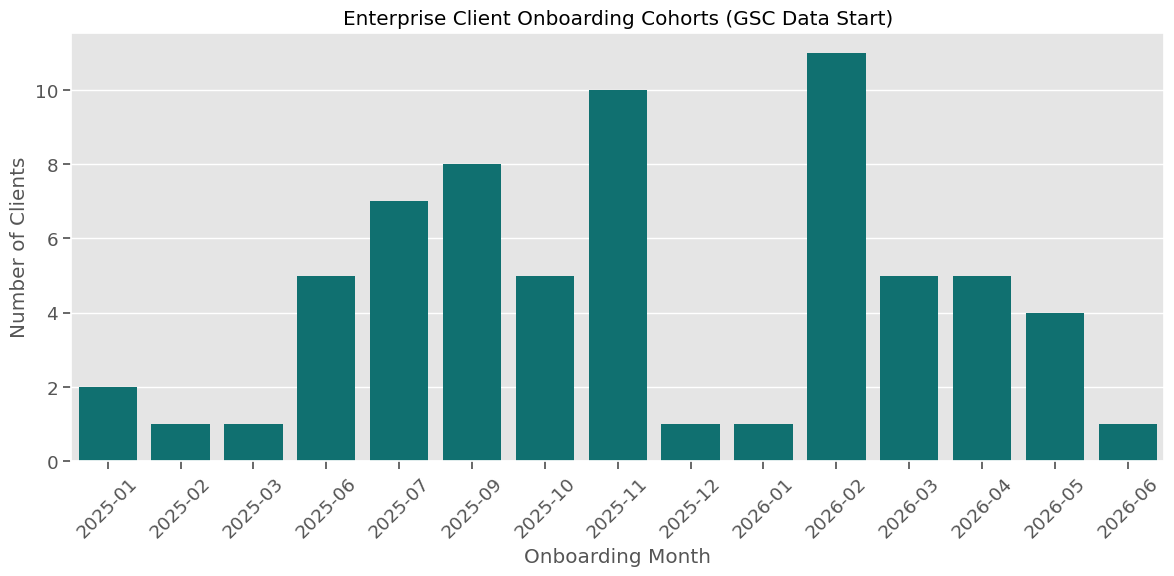

In [13]:
client_df = con.sql("""
    SELECT gsc_data_start, COUNT(*) as client_count
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet')
    GROUP BY gsc_data_start
    ORDER BY gsc_data_start
""").df()

client_df['gsc_data_start'] = pd.to_datetime(client_df['gsc_data_start'])
client_df['cohort_month'] = client_df['gsc_data_start'].dt.to_period('M')
cohort_counts = client_df.groupby('cohort_month')['client_count'].sum().reset_index()
cohort_counts['cohort_month'] = cohort_counts['cohort_month'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=cohort_counts, x='cohort_month', y='client_count', color='teal')
plt.title('Enterprise Client Onboarding Cohorts (GSC Data Start)')
plt.xticks(rotation=45)
plt.ylabel('Number of Clients')
plt.xlabel('Onboarding Month')
plt.tight_layout()
plt.show()

## 3. Content Profiling
Let's analyze the `dim_content` table to understand the distribution of words and character counts across the half a million web pages we are tracking.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_type,total_pages,avg_word_count,avg_competition,avg_search_volume
0,keyword article,459174,2599.062197,NaN,211.484693
1,feedly article,57024,1751.684808,NaN,NaN
2,comparison article,3408,3310.179148,NaN,0.002937


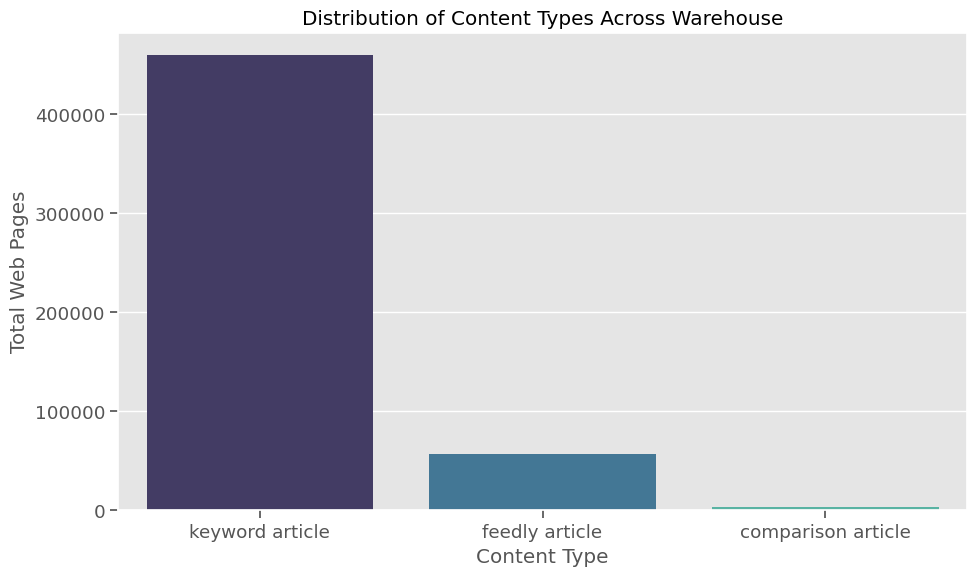

In [14]:
content_stats = con.sql("""
    SELECT
        content_type,
        COUNT(*) as total_pages,
        AVG(TRY_CAST(word_count AS DOUBLE)) as avg_word_count,
        AVG(TRY_CAST(competition_level AS DOUBLE)) as avg_competition,
        AVG(TRY_CAST(search_volume AS DOUBLE)) as avg_search_volume
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/dim_content.parquet')
    WHERE content_type IS NOT NULL
    GROUP BY content_type
    ORDER BY total_pages DESC
""").df()

display(content_stats)

plt.figure(figsize=(10, 6))
sns.barplot(data=content_stats, x='content_type', y='total_pages', hue='content_type', palette='mako', legend=False)
plt.title('Distribution of Content Types Across Warehouse')
plt.ylabel('Total Web Pages')
plt.xlabel('Content Type')
plt.tight_layout()
plt.show()



## 4. The Long Tail of SEO Traffic
To avoid scanning 78.8M rows for an EDA chart, we will sample the massive `month=2026-06` partition (which contains ~6M rows itself) to observe the distribution of impressions across content pages. We expect to see a massive Pareto distribution (a few pages get most of the traffic).

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

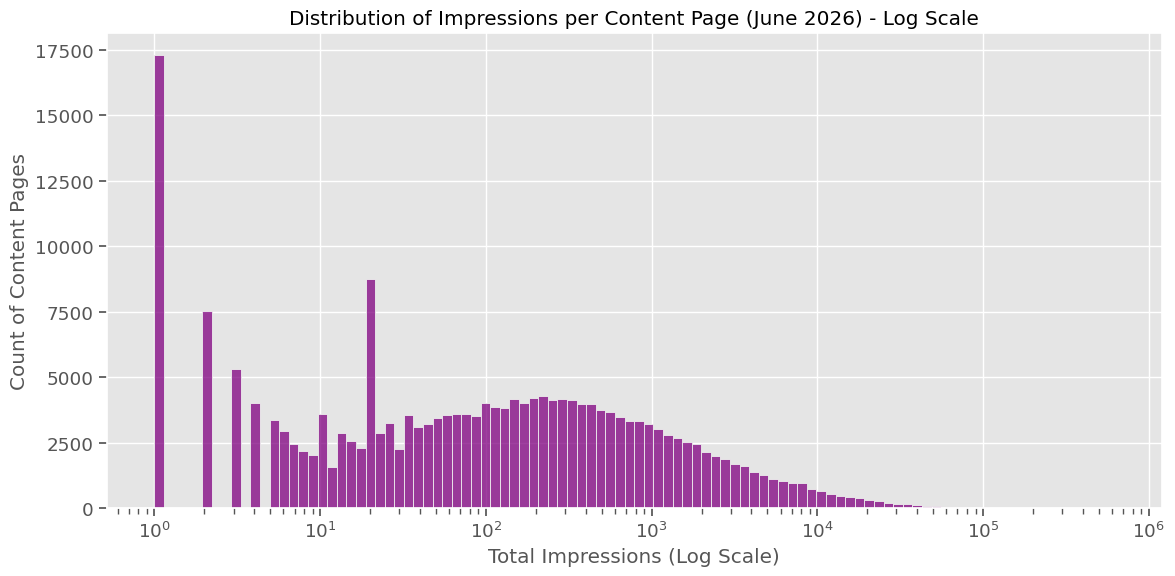

In [15]:
traffic_distribution = con.sql("""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) as total_impressions
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-06/*.parquet')
    GROUP BY content_hash_id
    HAVING total_impressions > 0
""").df()

plt.figure(figsize=(12, 6))
sns.histplot(traffic_distribution['total_impressions'], bins=100, log_scale=(True, False), color='purple')
plt.title('Distribution of Impressions per Content Page (June 2026) - Log Scale')
plt.xlabel('Total Impressions (Log Scale)')
plt.ylabel('Count of Content Pages')
plt.tight_layout()
plt.show()

## 5. Query Depth Profiling
The `fact_content_query_90d` table contains 90-day aggregations at the *Query* level. Let's see how many distinct search queries typically drive traffic to a single piece of content.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

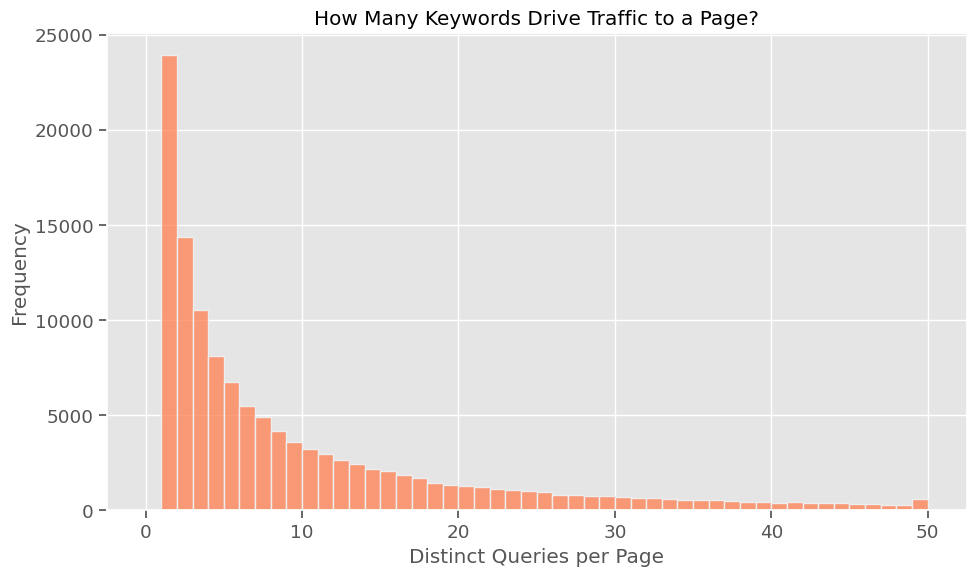

In [16]:
query_depth = con.sql("""
    SELECT
        content_hash_id,
        COUNT(DISTINCT query_hash_id) as distinct_queries_mapped
    FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_query_90d.parquet')
    GROUP BY content_hash_id
""").df()

plt.figure(figsize=(10, 6))
sns.histplot(query_depth['distinct_queries_mapped'], bins=50, color='coral', binrange=(0, 50))
plt.title('How Many Keywords Drive Traffic to a Page?')
plt.xlabel('Distinct Queries per Page')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()